## 1. Install Dependencies

In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 9.4 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports & Config

In [3]:
import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath('dl_service')          # adjust if running from elsewhere
DATA_FILE   = os.path.join(BASE_DIR, 'data', 'cattle_training_data.csv')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
SEQUENCE_LENGTH  = 30
FEATURES         = ['temperature', 'humidity', 'heartRate', 'distance', 'hour', 'day_of_week']
N_FEATURES       = len(FEATURES)
CONTAMINATION    = 0.02   # 2 % anomaly threshold
GLOBAL_EPOCHS    = 50
PER_COW_EPOCHS   = 30
BATCH_SIZE       = 32

print(f'TF version : {tf.__version__}')
print(f'Models dir : {MODELS_DIR}')

TF version : 2.16.1
Models dir : /Users/malshan/Documents/cattle-backend/dl_service/models


## 3. Load & Explore Data

In [4]:
df = pd.read_csv(DATA_FILE, parse_dates=['timestamp'])
print(f'Shape: {df.shape}')
df.head()

Shape: (21600, 11)


,timestamp,cattle_id,temperature,heartRate,humidity,distance,hour,day_of_week,is_anomaly,anomaly_type,heart_rate
0,2024-01-01 00:00:00,COW_001,38.53,49.1,73.9,1.4,0,0,0,normal,NaN
1,2024-01-01 00:10:00,COW_001,38.68,50.7,75.0,9.9,0,0,0,normal,NaN
2,2024-01-01 00:20:00,COW_001,38.38,51.8,70.5,2.9,0,0,0,normal,NaN
3,2024-01-01 00:30:00,COW_001,38.38,39.2,74.8,2.8,0,0,0,normal,NaN
4,2024-01-01 00:40:00,COW_001,38.30,50.9,69.2,4.9,0,0,0,normal,NaN


In [5]:
print('Cattle IDs:', df['cattle_id'].unique())
print('\nAnomaly distribution:')
print(df['is_anomaly'].value_counts())
df[FEATURES].describe()

Cattle IDs: ['COW_001' 'COW_002' 'COW_003' 'COW_004' 'COW_005']

Anomaly distribution:
is_anomaly
0    20955
1      645
Name: count, dtype: int64


,temperature,humidity,heartRate,distance,hour,day_of_week
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000
mean,38.857059,65.169472,60.227472,24.288931,11.500000,2.966667
std,0.484450,6.754728,11.521406,28.131365,6.922347,1.974606
min,37.920000,46.900000,20.200000,0.000000,0.000000,0.000000
25%,38.540000,59.800000,51.900000,4.700000,5.750000,1.000000
50%,38.810000,65.100000,59.900000,13.300000,11.500000,3.000000
75%,39.080000,70.300000,68.000000,33.100000,17.250000,5.000000
max,42.500000,99.700000,129.600000,120.000000,23.000000,6.000000


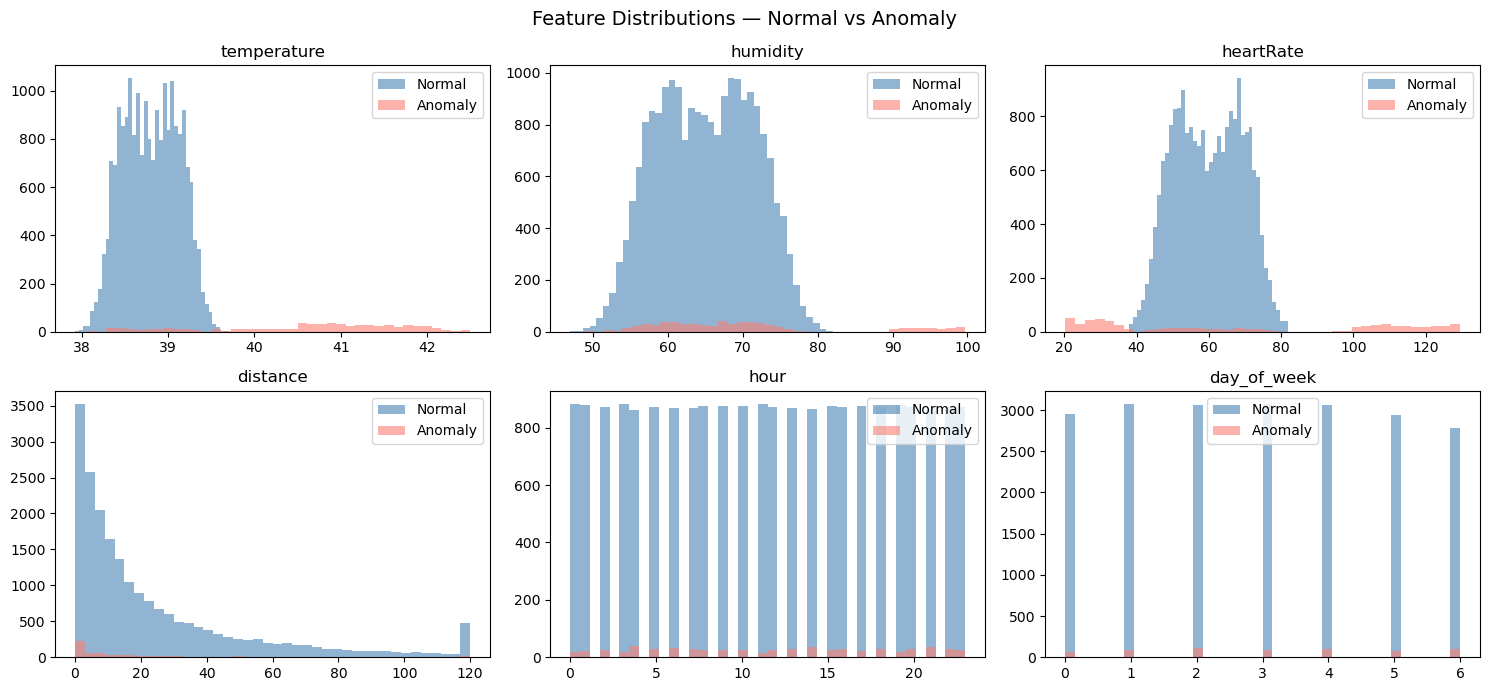

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flat, FEATURES):
    normal   = df[df['is_anomaly'] == 0][feat]
    anomalous = df[df['is_anomaly'] == 1][feat]
    ax.hist(normal, bins=40, alpha=0.6, label='Normal', color='steelblue')
    ax.hist(anomalous, bins=40, alpha=0.6, label='Anomaly', color='salmon')
    ax.set_title(feat); ax.legend()
plt.suptitle('Feature Distributions — Normal vs Anomaly', fontsize=14)
plt.tight_layout(); plt.show()

## 4. Preprocessing — Sequences & Scaling

In [7]:
# Keep only NORMAL data for training (autoencoder learns 'normal' pattern)
df_train = df[df['is_anomaly'] == 0].copy()
df_train = df_train.sort_values(['cattle_id', 'timestamp']).reset_index(drop=True)
print(f'Training rows (normal only): {len(df_train)}')

scalers = {}

def create_sequences(data_df, features, seq_len):
    arr = data_df[features].values.astype('float32')
    seqs, labels = [], []
    for i in range(len(arr) - seq_len + 1):
        seqs.append(arr[i : i + seq_len])
        labels.append(data_df['is_anomaly'].values[i + seq_len - 1] if 'is_anomaly' in data_df else 0)
    return np.array(seqs, dtype='float32'), np.array(labels)

def normalize(cattle_id, seqs, fit=False):
    shape = seqs.shape
    flat  = seqs.reshape(-1, N_FEATURES)
    if fit or cattle_id not in scalers:
        sc = MinMaxScaler()
        sc.fit(flat)
        scalers[cattle_id] = sc
    return scalers[cattle_id].transform(flat).reshape(shape).astype('float32')

# Build GLOBAL sequences (all cattle combined)
global_seqs, _ = create_sequences(df_train, FEATURES, SEQUENCE_LENGTH)
global_seqs_norm = normalize('global', global_seqs, fit=True)
print(f'Global sequence shape: {global_seqs_norm.shape}')

Training rows (normal only): 20955
Global sequence shape: (20926, 30, 6)


## 5. Build LSTM Autoencoder Architecture

In [8]:
def build_autoencoder(seq_len, n_features, dropout=0.2):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        # Encoder
        layers.LSTM(128, activation='tanh', return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(64,  activation='tanh', return_sequences=False),
        layers.Dropout(dropout),
        layers.RepeatVector(seq_len),
        # Decoder
        layers.LSTM(64,  activation='tanh', return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(128, activation='tanh', return_sequences=True),
        layers.TimeDistributed(layers.Dense(n_features)),
    ])
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
    return model

model_preview = build_autoencoder(SEQUENCE_LENGTH, N_FEATURES)
model_preview.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 6)          │           774 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,142 (981.02 KB)

 Trainable params: 251,142 (981.02 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train Global Model

In [9]:
global_model = build_autoencoder(SEQUENCE_LENGTH, N_FEATURES)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history_global = global_model.fit(
    global_seqs_norm, global_seqs_norm,
    epochs=GLOBAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

global_model_path = os.path.join(MODELS_DIR, 'global_model.h5')
global_model.save(global_model_path)
print(f'Global model saved → {global_model_path}')

Epoch 1/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - loss: 0.0232 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 2/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - loss: 0.0149 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 3/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - loss: 0.0137 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 4/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - loss: 0.0132 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 5/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - loss: 0.0129 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 6/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - loss: 0.0127 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 7/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - loss: 0.0126 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 8/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - loss: 0.0124 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 9/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - loss: 0.0124 - val_loss: 0.0121 - learning_rate:

Global model saved → /Users/malshan/Documents/cattle-backend/dl_service/models/global_model.h5


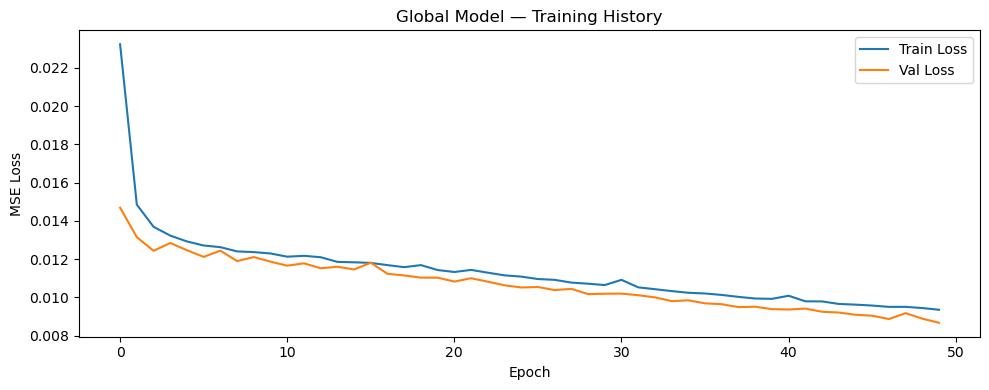

In [11]:
# Plot global training history
plt.figure(figsize=(10, 4))
plt.plot(history_global.history['loss'],     label='Train Loss')
plt.plot(history_global.history['val_loss'], label='Val Loss')
plt.title('Global Model — Training History')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()
plt.tight_layout(); plt.show()

## 7. Train Per-Cow Models

In [ ]:
cattle_ids = df_train['cattle_id'].unique()
print(f'Training per-cow models for: {list(cattle_ids)}')

per_cow_models    = {}
per_cow_thresholds = {}

for cid in cattle_ids:
    cow_df = df_train[df_train['cattle_id'] == cid].copy()
    seqs, _ = create_sequences(cow_df, FEATURES, SEQUENCE_LENGTH)

    if len(seqs) < SEQUENCE_LENGTH:
        print(f'    Skipping {cid}: not enough data')
        continue

    seqs_norm = normalize(cid, seqs, fit=True)
    print(f'\n🐄 [{cid}] — {len(seqs_norm)} sequences')

    model = build_autoencoder(SEQUENCE_LENGTH, N_FEATURES)
    model.fit(
        seqs_norm, seqs_norm,
        epochs=PER_COW_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ],
        verbose=0,
    )

    # Save model
    path = os.path.join(MODELS_DIR, f'cattle_{cid}.h5')
    model.save(path)

    # Calculate threshold (98th percentile of reconstruction errors)
    reconstructions = model.predict(seqs_norm, verbose=0)
    errors = np.mean(np.square(seqs_norm - reconstructions), axis=(1, 2))
    threshold = float(np.percentile(errors, 100 * (1 - CONTAMINATION)))
    joblib.dump(threshold, os.path.join(MODELS_DIR, f'threshold_cattle_{cid}.joblib'))

    per_cow_models[cid]     = model
    per_cow_thresholds[cid] = threshold
    print(f'   Saved | Threshold: {threshold:.6f}')

# Save all scalers
joblib.dump(scalers, os.path.join(MODELS_DIR, 'scalers.joblib'))
print('\n All per-cow models trained and saved!')

## 8. Load Saved Models & Run Inference

In [13]:
# ── Load everything from disk ─────────────────────────────────────────────────
loaded_scalers = joblib.load(os.path.join(MODELS_DIR, 'scalers.joblib'))

def load_model_and_threshold(cattle_id):
    model_path = os.path.join(MODELS_DIR, f'cattle_{cattle_id}.h5')
    thresh_path = os.path.join(MODELS_DIR, f'threshold_cattle_{cattle_id}.joblib')
    if not os.path.exists(model_path):
        print(f'No model for {cattle_id}, using global fallback')
        model_path = os.path.join(MODELS_DIR, 'global_model.h5')
        thresh_path = os.path.join(MODELS_DIR, 'global_threshold.joblib')
    m = models.load_model(model_path)
    t = joblib.load(thresh_path)
    return m, t

def predict_single(cattle_id, sequence_df):
    """Predict anomaly for one 30-row DataFrame window."""
    seqs, _ = create_sequences(sequence_df, FEATURES, SEQUENCE_LENGTH)
    scaler  = loaded_scalers.get(cattle_id) or loaded_scalers.get('global')
    flat    = seqs.reshape(-1, N_FEATURES)
    norm    = scaler.transform(flat).reshape(seqs.shape).astype('float32')

    model, threshold = load_model_and_threshold(cattle_id)
    recon  = model.predict(norm, verbose=0)
    errors = np.mean(np.square(norm - recon), axis=(1, 2))
    flags  = errors > threshold
    return errors, flags, threshold

print('Loader functions ready ')

Loader functions ready 


## 9. Evaluate on Full Dataset (All Cattle)

In [14]:
all_errors, all_labels, all_preds = [], [], []

for cid in df['cattle_id'].unique():
    cow_df = df[df['cattle_id'] == cid].sort_values('timestamp').reset_index(drop=True)
    if len(cow_df) < SEQUENCE_LENGTH:
        continue

    scaler = loaded_scalers.get(cid) or loaded_scalers.get('global')
    model, threshold = load_model_and_threshold(cid)

    seqs, labels = create_sequences(cow_df, FEATURES, SEQUENCE_LENGTH)
    flat = seqs.reshape(-1, N_FEATURES)
    norm = scaler.transform(flat).reshape(seqs.shape).astype('float32')

    recon  = model.predict(norm, verbose=0)
    errors = np.mean(np.square(norm - recon), axis=(1, 2))
    preds  = (errors > threshold).astype(int)

    all_errors.extend(errors.tolist())
    all_labels.extend(labels.tolist())
    all_preds.extend(preds.tolist())
    print(f'{cid}: sequences={len(seqs)}, anomalies detected={preds.sum()}')

all_errors = np.array(all_errors)
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
print(f'\nTotal sequences evaluated: {len(all_labels)}')

ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

In [ ]:
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Anomaly']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Anomaly'],
            yticklabels=['True Normal', 'True Anomaly'])
plt.title('Confusion Matrix'); plt.tight_layout(); plt.show()

## 10. Visualise Reconstruction Errors Per Cattle

In [ ]:
cattle_ids_all = df['cattle_id'].unique()
fig, axes = plt.subplots(len(cattle_ids_all), 1, figsize=(14, 4 * len(cattle_ids_all)))
if len(cattle_ids_all) == 1:
    axes = [axes]

for ax, cid in zip(axes, cattle_ids_all):
    cow_df = df[df['cattle_id'] == cid].sort_values('timestamp').reset_index(drop=True)
    if len(cow_df) < SEQUENCE_LENGTH:
        continue

    scaler = loaded_scalers.get(cid) or loaded_scalers.get('global')
    model, threshold = load_model_and_threshold(cid)

    seqs, labels = create_sequences(cow_df, FEATURES, SEQUENCE_LENGTH)
    flat = seqs.reshape(-1, N_FEATURES)
    norm = scaler.transform(flat).reshape(seqs.shape).astype('float32')

    recon  = model.predict(norm, verbose=0)
    errors = np.mean(np.square(norm - recon), axis=(1, 2))

    ax.plot(errors, label='Reconstruction Error', color='steelblue', linewidth=0.8)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=f'Threshold ({threshold:.5f})')
    anomaly_idx = np.where(labels == 1)[0]
    if len(anomaly_idx):
        ax.scatter(anomaly_idx, errors[anomaly_idx], color='orange', s=15, zorder=5, label='True Anomaly')
    ax.set_title(f'Cattle {cid}'); ax.legend(loc='upper right'); ax.set_xlabel('Sequence Index'); ax.set_ylabel('MSE')

plt.suptitle('Reconstruction Errors — All Cattle', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 11. Load Existing Saved Models (Skip Training)

In [ ]:
# ── Run this cell INSTEAD of sections 6 & 7 if models are already trained ────
print('Loading pre-trained models from disk...')

loaded_scalers = joblib.load(os.path.join(MODELS_DIR, 'scalers.joblib'))

saved_h5 = [f for f in os.listdir(MODELS_DIR) if f.endswith('.h5')]
for fname in sorted(saved_h5):
    path = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(path) / 1024
    print(f'   {fname:<35} {size:.1f} KB')

print('\nAll models ready for inference!')